In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
np.random.seed(42)
X_raw, y_raw = make_classification(
    n_samples=1000, n_features=10, n_informative=6,
    n_redundant=2, random_state=42
)

feature_names = ['Income', 'Age', 'LoanAmount', 'CreditHistory',
                 'DebtRatio', 'Employment', 'Savings', 'Assets',
                 'PreviousLoans', 'MonthsEmployed']

df = pd.DataFrame(X_raw, columns=feature_names)
df['Creditability'] = y_raw  # 1 = Good Credit, 0 = Bad Credit

print("✅ Dataset created!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

✅ Dataset created!
Shape: (1000, 11)

First 5 rows:
     Income       Age  LoanAmount  CreditHistory  DebtRatio  Employment  \
0 -1.030931  1.391626    0.547274       0.928932  -1.738880    1.250002   
1 -2.766254  1.247870   -0.303691       1.083145   0.710836    1.968202   
2 -0.558987  0.299849    1.527071       0.360442  -1.360209    1.100793   
3 -1.350289 -2.046078   -0.614264       0.126459  -0.783923    5.895026   
4 -0.275754 -0.728495    0.027727      -0.660834  -1.928161    3.544945   

    Savings    Assets  PreviousLoans  MonthsEmployed  Creditability  
0  1.332551  1.578256       2.124722       -0.318434              0  
1 -1.794192  2.346422       1.700778       -0.001190              1  
2 -0.755951  1.331933       2.041105       -0.824404              0  
3 -0.915477 -3.184768      -0.399260       -3.920960              0  
4  1.446944 -1.111662       0.313766       -2.376528              0  


In [3]:
print("\n📊 Dataset Info:")
print(df.info())

print("\n📈 Basic Statistics:")
print(df.describe())

print("\n🎯 Target Distribution (1=Good Credit, 0=Bad Credit):")
print(df['Creditability'].value_counts())



📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Income          1000 non-null   float64
 1   Age             1000 non-null   float64
 2   LoanAmount      1000 non-null   float64
 3   CreditHistory   1000 non-null   float64
 4   DebtRatio       1000 non-null   float64
 5   Employment      1000 non-null   float64
 6   Savings         1000 non-null   float64
 7   Assets          1000 non-null   float64
 8   PreviousLoans   1000 non-null   float64
 9   MonthsEmployed  1000 non-null   float64
 10  Creditability   1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB
None

📈 Basic Statistics:
            Income          Age   LoanAmount  CreditHistory    DebtRatio  \
count  1000.000000  1000.000000  1000.000000    1000.000000  1000.000000   
mean     -1.012153     0.532850    -0.076207      -0.013345   

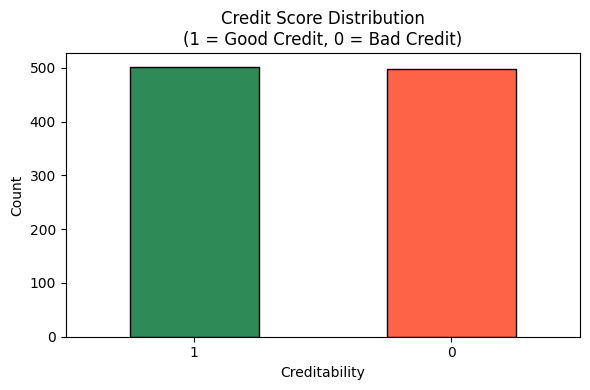

✅ Distribution chart saved!


In [4]:
plt.figure(figsize=(6, 4))
df['Creditability'].value_counts().plot(
    kind='bar', color=['seagreen', 'tomato'], edgecolor='black'
)
plt.title('Credit Score Distribution\n(1 = Good Credit, 0 = Bad Credit)')
plt.xlabel('Creditability')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('credit_distribution.png')
plt.show()
print("✅ Distribution chart saved!")


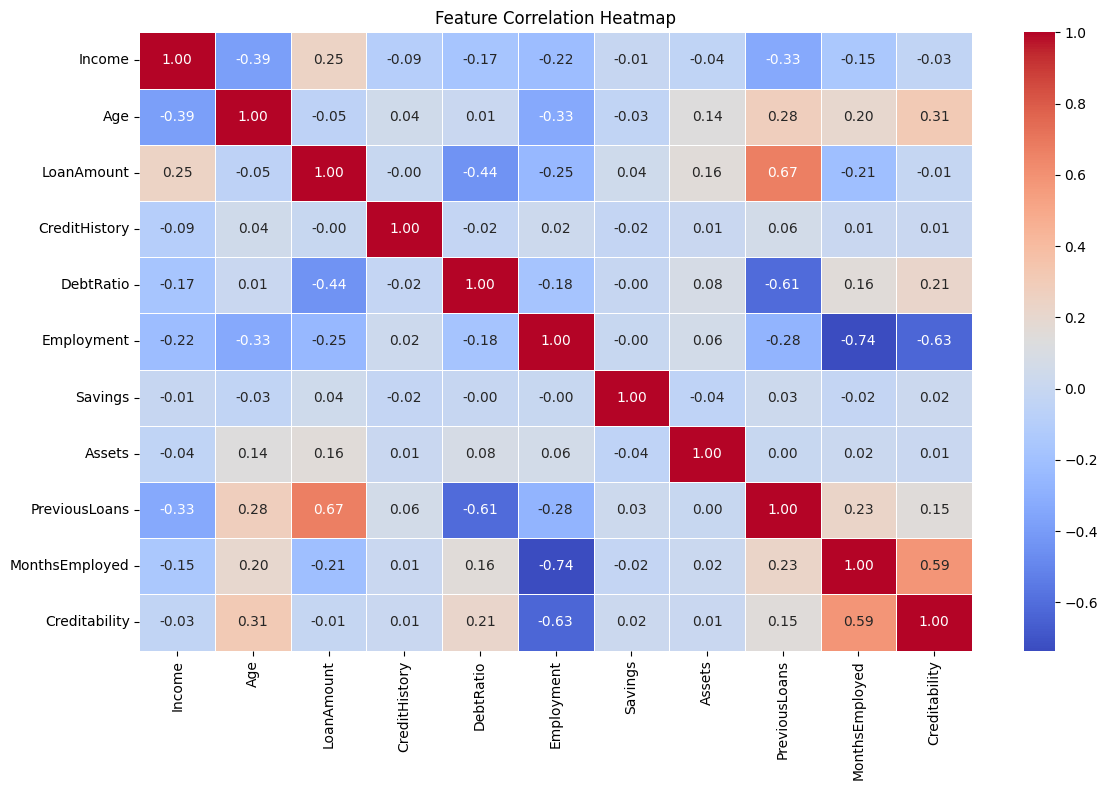

✅ Heatmap saved!


In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('credit_heatmap.png')
plt.show()
print("✅ Heatmap saved!")




🔑 Top Features by Correlation with Target:
Creditability     1.000000
Employment        0.632028
MonthsEmployed    0.585634
Age               0.309918
DebtRatio         0.213648
PreviousLoans     0.147882
Income            0.034823
Savings           0.022995
LoanAmount        0.010516
CreditHistory     0.009793
Assets            0.008269
Name: Creditability, dtype: float64


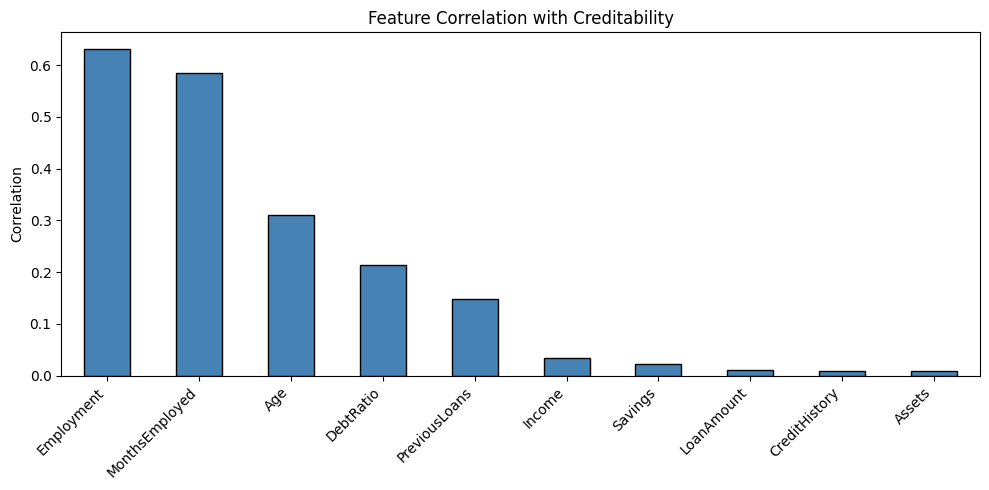

✅ Feature importance chart saved!


In [6]:
correlations = df.corr()['Creditability'].abs().sort_values(ascending=False)
print("\n🔑 Top Features by Correlation with Target:")
print(correlations)

plt.figure(figsize=(10, 5))
correlations.drop('Creditability').plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('Feature Correlation with Creditability')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("✅ Feature importance chart saved!")

In [8]:
X = df.drop('Creditability', axis=1)
y = df['Creditability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"✅ Train size: {X_train.shape}, Test size: {X_test.shape}")
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'model': model, 'accuracy': acc, 'roc_auc': roc_auc,
        'y_pred': y_pred, 'y_proba': y_proba
    }

    print(f"\n🤖 {name}")
    print(f"   Accuracy : {acc:.4f}")
    print(f"   ROC-AUC  : {roc_auc:.4f}")

✅ Train size: (800, 10), Test size: (200, 10)

🤖 Logistic Regression
   Accuracy : 0.8200
   ROC-AUC  : 0.8797

🤖 Decision Tree
   Accuracy : 0.8250
   ROC-AUC  : 0.8250

🤖 Random Forest
   Accuracy : 0.8900
   ROC-AUC  : 0.9582



🏆 Best Model: Random Forest

📋 Classification Report:
              precision    recall  f1-score   support

  Bad Credit       0.91      0.87      0.89       100
 Good Credit       0.88      0.91      0.89       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



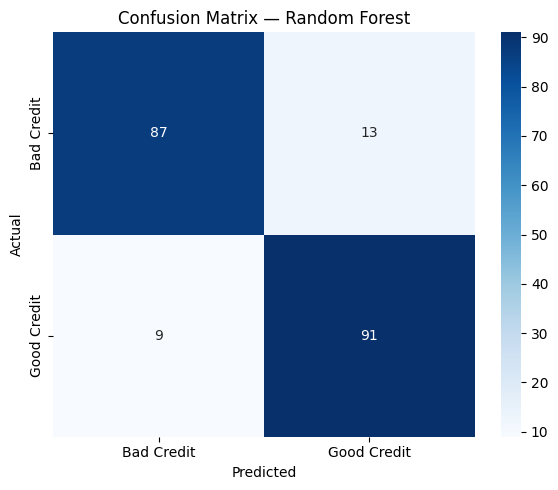

✅ Confusion matrix saved!


In [10]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best      = results[best_name]

print(f"\n🏆 Best Model: {best_name}")
print("\n📋 Classification Report:")
print(classification_report(y_test, best['y_pred'],
                             target_names=['Bad Credit', 'Good Credit']))
cm = confusion_matrix(y_test, best['y_pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bad Credit', 'Good Credit'],
            yticklabels=['Bad Credit', 'Good Credit'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('credit_confusion_matrix.png')
plt.show()
print("✅ Confusion matrix saved!")



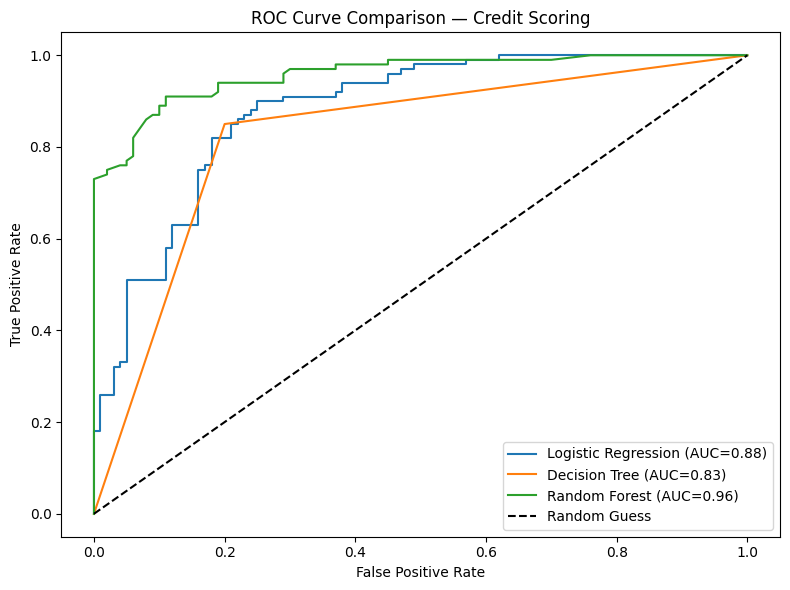

✅ ROC curve saved!


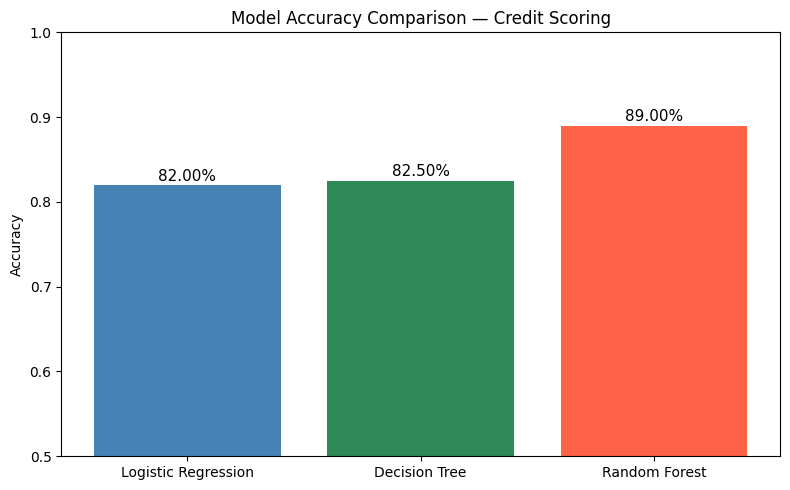

✅ Model comparison chart saved!


In [12]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — Credit Scoring')
plt.legend()
plt.tight_layout()
plt.savefig('credit_roc_curve.png')
plt.show()
print("✅ ROC curve saved!")
names      = list(results.keys())
accuracies = [results[n]['accuracy'] for n in names]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, accuracies, color=['steelblue', 'seagreen', 'tomato'])
plt.ylim(0.5, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison — Credit Scoring')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('credit_model_comparison.png')
plt.show()
print("✅ Model comparison chart saved!")



In [13]:
new_applicant = pd.DataFrame([[55000, 35, 15000, 0.8,
                                0.3, 5, 20000, 50000, 2, 48]],
                              columns=feature_names)
new_scaled   = scaler.transform(new_applicant)
prediction   = best['model'].predict(new_scaled)[0]
probability  = best['model'].predict_proba(new_scaled)[0][1]

print("\n💳 New Applicant Credit Prediction")
print(f"   Result     : {'✅ Good Credit' if prediction == 1 else '❌ Bad Credit Risk'}")
print(f"   Confidence : {probability:.2%}")

print("\n✅ Task 1 Complete! All outputs saved as PNG files.")


💳 New Applicant Credit Prediction
   Result     : ❌ Bad Credit Risk
   Confidence : 42.00%

✅ Task 1 Complete! All outputs saved as PNG files.
